In [15]:
import matplotlib.pyplot as plt
import numpy as np
import sys, torch, matplotlib
from sbi.utils import MultipleIndependent
from torch.distributions import Uniform
from torch import nn
from sbi import utils as utils
from sbi.analysis import pairplot
from sbi.inference import NPE
import scipy.stats as st
import os, pickle
from matplotlib.gridspec import GridSpec
sys.path.append('/Users/martinbreyton/INS_Code/PhD/')
sys.path.append('/Users/martinbreyton/INS_Code/PhD/scripts/python')
from sbi.neural_nets import posterior_nn

In [16]:
results_path = '/Users/martinbreyton/INS_Code/PhD/results/sub-003/sbi_homogeneous_v2_bak'
atlas_LUT = "/Users/martinbreyton/INS_Code/SCZ_Reports/data/Schaefer_luts/MRtrix LUT/Schaefer2018_100Parcels_7Networks_order_LUT.txt"
lut_aseg  = np.genfromtxt(atlas_LUT, usecols=0, dtype=int)[1:101]
lut_names = np.genfromtxt(atlas_LUT, usecols=1, dtype=str)[1:101]
names = ['_'.join(name.split('_')[1:3]) for name in lut_names]
names_idx = sorted([names.index(name) for name in set(names)])

In [17]:
X = []
Y = []
SEEDS = [f"{int(seed)}" for seed in np.arange(500)]
for seed in SEEDS:
    
    js = np.load(f"{results_path}/params_mpr_homogeneous_seed{seed}_sub-003.npz")['js'][:,0]
    etas = np.load(f"{results_path}/params_mpr_homogeneous_seed{seed}_sub-003.npz")['etas'][:,0]
    feats = np.load(f"{results_path}/feat_mpr_seed{seed}.npz")['bold'][:,6:]
    vbi_fc = feats[:,:26]
    vbi_fc = np.delete(vbi_fc, 19, 1)
    vbi_fcd = feats[:,27:27+26]
    vbi_fcd = np.delete(vbi_fcd, 19, 1)
    zero_cross = feats[:,-500:-400]
    X.append(np.c_[js, etas, vbi_fc, vbi_fcd, zero_cross.mean(axis=1)])
    # X.append(np.c_[vbi_fc])
    Y.append([int(seed), etas, js])


In [18]:
np.random.seed(42)
torch.manual_seed(42)
X = np.vstack(X)
print(X.shape)
# print(X[0,:4])
to_del = np.unique(np.argwhere(np.isnan(X))[:,1], return_counts=True)[0][np.unique(np.argwhere(np.isnan(X))[:,1], return_counts=True)[1]==X.shape[0]] # del empty features
print(to_del)
X = np.delete(X, to_del, 1)
print(X.shape)
X = np.delete(X, np.unique(np.argwhere(np.isnan(X))[:,0]), 0) # delete datapoints where at least one feature is nan
print(X.shape)

(40000, 53)
[]
(40000, 53)
(38685, 53)


In [19]:
np.unique(np.argwhere(np.isnan(X))[:,1], return_counts=True)

(array([], dtype=int64), array([], dtype=int64))

In [20]:
# X = np.delete(X, np.argwhere(np.var(X[:,3:], axis=0)<.1)+3, axis=1)
to_remove = np.random.choice(X.shape[0], 500, replace=False)
GT = X[to_remove]
X = np.delete(X, to_remove, 0)
np.random.shuffle(X)
print(GT.shape, X.shape)

(500, 53) (38185, 53)


In [21]:
np.save('gt_mpr_homogeneous_fixed_g_v2.npy', GT)

In [22]:
prior = MultipleIndependent(
    [Uniform(low=torch.tensor([8.]), high=torch.tensor([20.]))]*1+[Uniform(low=torch.tensor([-6.]), high=torch.tensor([-2.5]))]*1
)

In [23]:
x = torch.from_numpy(X[:,2:].astype('float32'))
theta = torch.from_numpy(X[:,:2].astype('float32'))

In [24]:
x.shape, theta.shape

(torch.Size([38185, 51]), torch.Size([38185, 2]))

In [25]:
maf = posterior_nn(
    model="maf", z_score_theta='independent', z_score_x='independent', embedding_net=nn.Identity(), num_transforms=5, hidden_features=50
)
inference = NPE(prior=prior, density_estimator=maf, device='cpu')
inference.append_simulations(theta, x)
density_estimator = inference.train(training_batch_size=200)
posterior = inference.build_posterior(density_estimator)

 Training neural network. Epochs trained: 58

KeyboardInterrupt: 

In [ ]:
with open('inference_mpr_homogeneous_fixed_g_v2.pkl', 'wb') as f:
    pickle.dump(posterior, f)

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

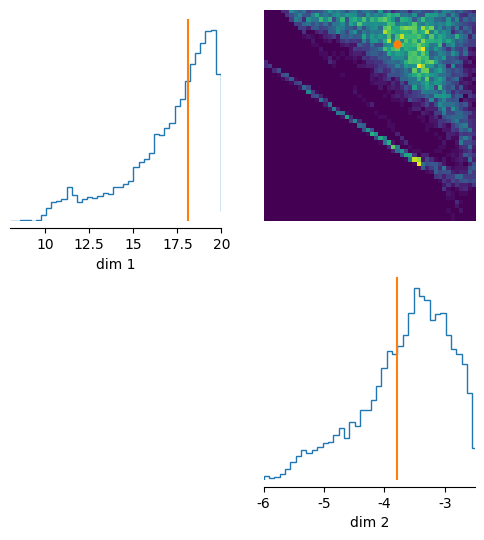

In [ ]:
samples = posterior.sample((10000,), x=GT[10,2:].astype('float32'))
limits = [[8, 20]]+[[-6,-2.5]]
_ = pairplot(
    samples, figsize=(6, 6),
    limits=limits,
    points=GT[10:11,:3]
)

In [158]:
# from matplotlib.pyplot import cm
# color = matplotlib.colormaps["tab10"].colors
# fig, ax = plt.subplots(1, 1, figsize=(4, 4))
# df = pd.read_csv(f'csvs/mlp_fre_cusp.csv', delimiter=',')
# ax.plot(df['eta'].values, df['j'].values, c='orange', linestyle='--',  linewidth=1)
# GT = np.load('gt_mpr_homogeneous_fixed_g.npy')
# # GT = np.delete(GT, 0, axis=0)

# MAPS = []
# for i, (gt, c) in enumerate(zip(GT[:10], color)):
#     print(f'{i}/{len(GT)}', end='\r')
#     posterior.set_default_x(gt[2:].astype('float32'))
#     rs = posterior.sample((10000,), show_progress_bars=False)
#     MAPS.append(rs)

#     ax.scatter(rs[::2,1], rs[::2,0], s=.01, c=c)
#     ax.scatter(gt[1], gt[0], s=50, marker='X', c=c, zorder=10000, edgecolors='k', linewidth=1)
#     ax.set_xlim((-7,-3))
#     ax.set_ylim((11,17))
#     # break
# ax.grid(False)
# plt.show()

In [22]:
GT_mpr = np.load('gt_mpr_homogeneous_fixed_g_v3.npy')
# GT = np.delete(GT, 0, axis=0)

MAPS_mpr = []
real_MAPS_mpr = []
for i, gt in enumerate(GT_mpr):
    print(f'{i}/{len(GT_mpr)}', end='\r')
    with open('inference_mpr_homogeneous_fixed_g_v3.pkl', 'rb') as f:
        posterior = pickle.load(f)
    posterior.set_default_x(gt[2:].astype('float32'))
    rs = posterior.sample((10000,), show_progress_bars=False)
    # m = posterior.map(show_progress_bars=False)
    MAPS_mpr.append(rs)
    # real_MAPS_mpr.append(m)

In [54]:
X = []
SEEDS = [f"{int(seed)}" for seed in np.arange(800)]
for seed in SEEDS:
    g = np.load(f"{results_path}/mlp_qif_internal/params_mlp_qif_internal_homogeneous_seed{seed}_sub-003.npz")['gs'].squeeze()
    js = np.load(f"{results_path}/mlp_qif_internal/params_mlp_qif_internal_homogeneous_seed{seed}_sub-003.npz")['js'].squeeze()[:,0]
    etas = np.load(f"{results_path}/mlp_qif_internal/params_mlp_qif_internal_homogeneous_seed{seed}_sub-003.npz")['etas'].squeeze()[:,0]
    ps = np.load(f"{results_path}/mlp_qif_internal/params_mlp_qif_internal_homogeneous_seed{seed}_sub-003.npz")['ps'].squeeze()[:,0]
    feats = np.load(f"{results_path}/mlp_qif_internal/feat_mlp_qif_internal_seed{seed}.npz")['bold'][:,[5,6]]
    X.append(np.c_[js, etas, ps, feats])

In [55]:
X = np.vstack(X)
to_del = np.unique(np.argwhere(np.isnan(X))[:,1], return_counts=True)[0][np.unique(np.argwhere(np.isnan(X))[:,1], return_counts=True)[1]==X.shape[0]]
print(to_del)
X = np.delete(X, to_del, 1)
print(X.shape)
X = np.delete(X, np.unique(np.argwhere(np.isnan(X))[:,0]), 0) # delete datapoints where at least one feature is nan
print(X.shape)
np.random.seed(42)
to_remove = np.random.choice(X.shape[0], 500, replace=False)
GT = X[to_remove]
GT.shape, X.shape
X = np.delete(X, to_remove, 0)
np.random.seed(0)
np.random.shuffle(X)
X.shape
np.save('gt_mlp_qif_homogeneous_fixed_g_v3.npy', GT)
prior = MultipleIndependent(
    [Uniform(low=torch.tensor([8.]), high=torch.tensor([20.]))]*1+[Uniform(low=torch.tensor([-6.]), high=torch.tensor([-2.5]))]+[Uniform(low=torch.tensor([.6]), high=torch.tensor([1.]))]
)
x = torch.from_numpy(X[:,3:].astype('float32'))
theta = torch.from_numpy(X[:,:3].astype('float32'))

[]
(64000, 5)
(64000, 5)


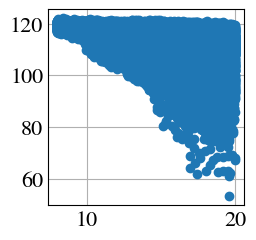

In [59]:
plt.scatter(X[:,0], X[:,4])

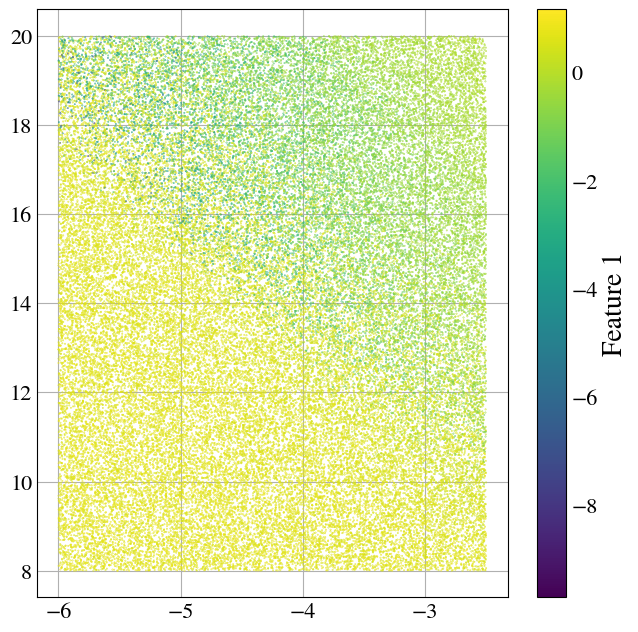

In [67]:

fig, ax = plt.subplots(1, 1, figsize=(6,6))
plt.scatter(X[:,1], X[:,0], c=st.zscore(X[:,-1]), cmap='viridis', s=.1)
plt.colorbar(label='Feature 1')
plt.show()

In [26]:
from sbi.neural_nets import posterior_nn
maf = posterior_nn(
    model="maf", z_score_theta='independent', z_score_x='independent', embedding_net=nn.Identity(), num_transforms=10, hidden_features=50
)
inference = NPE(prior=prior, density_estimator=maf, device='cpu')
inference.append_simulations(theta, x)
density_estimator = inference.train(training_batch_size=200)
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 167 epochs.

In [27]:
with open('inference_mlp_qif_homogeneous_fixed_g_v3.pkl', 'wb') as f:
    pickle.dump(posterior, f)

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

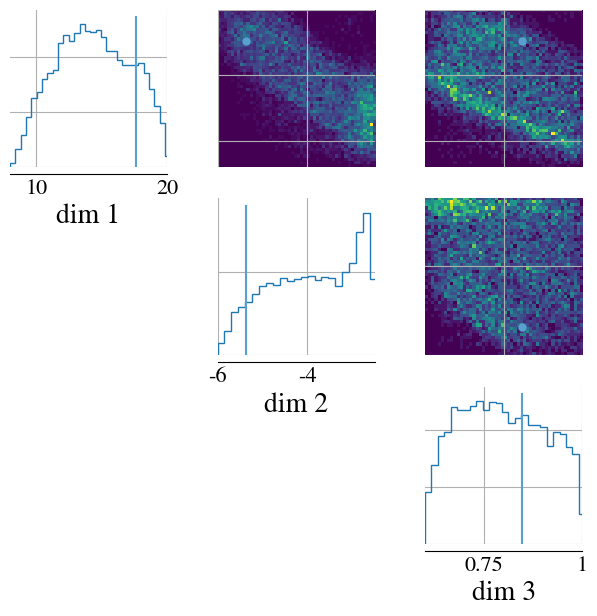

In [81]:
i = 10
GT = np.load('gt_mlp_qif_homogeneous_fixed_g_v3.npy')
with open('inference_mlp_qif_homogeneous_fixed_g_v3.pkl', 'rb') as f:
        posterior = pickle.load(f)
samples = posterior.sample((10000,), x=GT[i,3:].astype('float32'))
limits = [[8., 20.]]+[[-6,-2.5]]+[[.6,1.]]
_ = pairplot(
    samples, figsize=(6, 6),
    limits=limits,
    points=GT[i:i+1,:3]
)

In [33]:
# from matplotlib.pyplot import cm
# color = matplotlib.colormaps["tab10"].colors
# fig, ax = plt.subplots(1, 1, figsize=(4, 4))
# df = pd.read_csv(f'csvs/mlp_fre_cusp.csv', delimiter=',')
# ax.plot(df['eta'].values, df['j'].values, c='orange', linestyle='--',  linewidth=1)
# GT = np.load('gt_mlp_qif_homogeneous_fixed_g.npy')
# # GT = np.delete(GT, 0, axis=0)

# MAPS = []
# for i, (gt, c) in enumerate(zip(GT[:10], color)):
#     print(f'{i}/{len(GT)}', end='\r')
#     posterior.set_default_x(gt[3:].astype('float32'))
#     rs = posterior.sample((10000,), show_progress_bars=False)
#     MAPS.append(rs)

#     ax.scatter(rs[::2,1], rs[::2,0], s=.01, c=c)
#     ax.scatter(gt[1], gt[0], s=50, marker='X', c=c, zorder=10000, edgecolors='k', linewidth=1)
#     ax.set_xlim((-7,-3))
#     ax.set_ylim((11,17))
#     # break
# ax.grid(False)
# plt.show()

In [33]:
GT_mlp_qif = np.load('gt_mlp_qif_homogeneous_fixed_g_v3.npy')
MAPS_mlp_qif = []
real_MAPS_mlp_qif = []
for i, gt in enumerate(GT_mlp_qif):
    print(f'{i}/{len(GT_mlp_qif)}', end='\r')
    with open('inference_mlp_qif_homogeneous_fixed_g_v3.pkl', 'rb') as f:
        posterior = pickle.load(f)
    posterior.set_default_x(gt[3:].astype('float32'))
    rs = posterior.sample((10000,), show_progress_bars=False)
    # m = posterior.map(show_progress_bars=False)
    # real_MAPS_mlp_qif.append(m)
    MAPS_mlp_qif.append(rs)

In [9]:
# np.save('real_MAPS_mlp_qif.npy', np.array(real_MAPS_mlp_qif))

In [34]:
GT_mpr = np.load('gt_mpr_homogeneous_fixed_g_v3.npy')
MAPS_mlp_qif_p1 = []
real_MAPS_mlp_qif_p1 = []
for i, gt in enumerate(GT_mpr):
    print(f'{i}/{len(GT_mpr)}', end='\r')
    with open('inference_mlp_qif_homogeneous_fixed_g_v3.pkl', 'rb') as f:
        posterior = pickle.load(f)
    posterior.set_default_x(gt[2:].astype('float32'))
    rs = posterior.sample((10000,), show_progress_bars=False)
    # m = posterior.map(show_progress_bars=False)
    # real_MAPS_mlp_qif_p1.append(m)
    MAPS_mlp_qif_p1.append(rs)

KeyboardInterrupt: 

In [12]:
# np.save('real_MAPS_mlp_qif_p1.npy', np.array(real_MAPS_mlp_qif_p1))

In [13]:
# np.save('real_MAPS_crossed.npy', np.array(real_MAPS_crossed))

In [35]:
GT_mlp_qif = np.load('gt_mlp_qif_homogeneous_fixed_g_v3.npy')
# GT = np.delete(GT, 0, axis=0)

MAPS_crossed = []
real_MAPS_crossed = []
for i, gt in enumerate(GT_mlp_qif):
    print(f'{i}/{len(GT_mlp_qif)}', end='\r')
    with open('inference_mpr_homogeneous_fixed_g_v3.pkl', 'rb') as f:
        posterior = pickle.load(f)
    posterior.set_default_x(gt[3:].astype('float32'))
    rs = posterior.sample((10000,), show_progress_bars=False)
    # m = posterior.map(show_progress_bars=False)
    # real_MAPS_crossed.append(m)
    MAPS_crossed.append(rs)

In [12]:
axes.shape

(4, 3)

/var/folders/ht/k1bq940j1nzdxy0vc8gf2_d40000gn/T/ipykernel_1033/659263035.py:40: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x=s, y=z, c='k', s=5, cmap='viridis', alpha=.4, marker='x')
/var/folders/ht/k1bq940j1nzdxy0vc8gf2_d40000gn/T/ipykernel_1033/659263035.py:42: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x=s, y=z, c='r', s=10, cmap='viridis',  alpha=.4, facecolors='none', edgecolors='r', zorder=-1000)


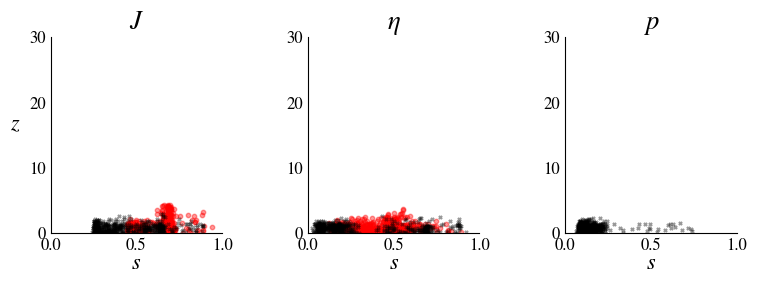

In [36]:
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['font.size']=16
matplotlib.rcParams['xtick.labelsize']=12
matplotlib.rcParams['ytick.labelsize']=12
matplotlib.rcParams['ytick.labelsize']=12
plt.style.use('_mpl-gallery')
networks = np.array([name.split('_')[1] for name in names[:50]])[names_idx[:7]]
fig = plt.figure(figsize=(7,2))
grid = GridSpec(ncols=3, nrows=1, figure=fig)
# fig, axes = plt.subplots(3, 3, figsize=(6,5))
ax1 = fig.add_subplot(grid[0,0])
ax2 = fig.add_subplot(grid[0,1], sharex=ax1, sharey=ax1)
ax3 = fig.add_subplot(grid[0,2], sharex=ax1, sharey=ax1)
axes = np.array([ax1, ax2, ax3])

# grid = GridSpec(ncols=3, nrows=3, figure=fig)
# axes = np.array([fig.add_subplot(grid[i,:]) for i in range(0,3)])
GT_mpr = np.load('gt_mpr_homogeneous_fixed_g_v3.npy')
GT_mlp_fixed_p = np.load('gt_mlp_fixed_p_homogeneous_fixed_g_v3.npy')
GT_mlp_qif = np.load('gt_mlp_qif_homogeneous_fixed_g_v3.npy')
for j, (MAPS, GT, name) in enumerate(zip([MAPS_mlp_qif, MAPS_crossed], [GT_mlp_qif, GT_mlp_qif], ['a', 'b', 'c', 'd'])):
    ss = []
    n = 3 if j==0 else 2
    for ax, i in zip(axes, range(n)):
        MAPS = np.array(MAPS)
        mu = np.mean(MAPS[:,:,i], axis=1)
        var = np.var(MAPS[:,:,i], axis=1)
        z = np.abs((mu-GT[:,i])/np.sqrt(var))
        match i:
            case 0:
                var_prior = (1/12)*(20-8)**2
            case 1:
                var_prior = (1/12)*(-6+2.5)**2
            case 2:
                var_prior = (1/12)*(1-.6)**2
        s = 1-(var/np.repeat(var_prior, len(var)).reshape(var.shape))
        ss.append(s)
        if j==0:
            ax.scatter(x=s, y=z, c='k', s=5, cmap='viridis', alpha=.4, marker='x')
        else:
            ax.scatter(x=s, y=z, c='r', s=10, cmap='viridis',  alpha=.4, facecolors='none', edgecolors='r', zorder=-1000)
        ax.set_xlim([0,1])
        ax.set_ylim([0,30])




        ax.grid(False)
        ax.spines[['right', 'top']].set_visible(False)
        net = networks[i][:3]

    axes[0].set_ylabel(rf'$z$', rotation=0, labelpad=10)
    [ax.set_xlabel(rf'$s$', rotation=0, labelpad=0) for ax in axes]
    axes[0].set_title(r'$J$')
    axes[1].set_title(r'$\eta$')
    axes[2].set_title(r'$p$')

# ax7.set_xlabel(rf'$s$', rotation=0, labelpad=10)
# ax9.set_xlabel(rf'$s$', rotation=0, labelpad=10)
        # ax.set_ylabel(rf'$\hat{{\eta}}$', rotation=0, labelpad=10) if j==0 else ax.set_ylabel(rf'$\hat{{J}}$', rotation=0, labelpad=10)
# ax.axvline(GT[0,i], color='r')
# ax.set_title(f"Theta {i}")
# axes[0].set_xlabel(rf'$J$')
# axes[1].set_xlabel(rf'$\eta$')
# axes[2].set_xlabel(rf'$p$')
plt.subplots_adjust(wspace=.5, hspace=.4)
# fig.savefig('paper_figs/inference_comp.png', dpi=600, facecolor='None', bbox_inches='tight')
plt.show()



/var/folders/ht/k1bq940j1nzdxy0vc8gf2_d40000gn/T/ipykernel_68485/1578219862.py:40: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x=s, y=z, c='k', s=5, cmap='viridis', alpha=.4, marker='x')
/var/folders/ht/k1bq940j1nzdxy0vc8gf2_d40000gn/T/ipykernel_68485/1578219862.py:42: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x=s, y=z, c='r', s=10, cmap='viridis',  alpha=.4, facecolors='none', edgecolors='r', zorder=-1000)


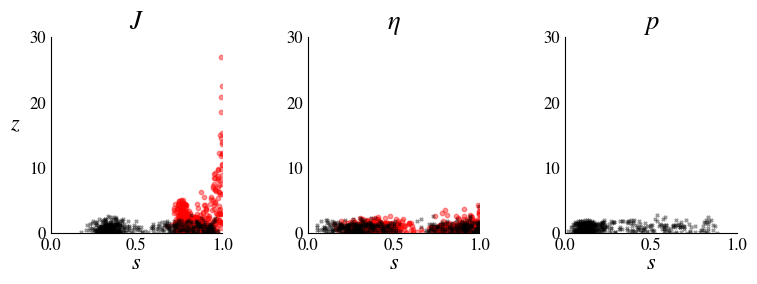

In [ ]:
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['font.size']=16
matplotlib.rcParams['xtick.labelsize']=12
matplotlib.rcParams['ytick.labelsize']=12
matplotlib.rcParams['ytick.labelsize']=12
plt.style.use('_mpl-gallery')
networks = np.array([name.split('_')[1] for name in names[:50]])[names_idx[:7]]
fig = plt.figure(figsize=(7,2))
grid = GridSpec(ncols=3, nrows=1, figure=fig)
# fig, axes = plt.subplots(3, 3, figsize=(6,5))
ax1 = fig.add_subplot(grid[0,0])
ax2 = fig.add_subplot(grid[0,1], sharex=ax1, sharey=ax1)
ax3 = fig.add_subplot(grid[0,2], sharex=ax1, sharey=ax1)
axes = np.array([ax1, ax2, ax3])

# grid = GridSpec(ncols=3, nrows=3, figure=fig)
# axes = np.array([fig.add_subplot(grid[i,:]) for i in range(0,3)])
GT_mpr = np.load('gt_mpr_homogeneous_fixed_g_v3.npy')
GT_mlp_fixed_p = np.load('gt_mlp_fixed_p_homogeneous_fixed_g_v3.npy')
GT_mlp_qif = np.load('gt_mlp_qif_homogeneous_fixed_g_v3.npy')
for j, (MAPS, GT, name) in enumerate(zip([MAPS_mlp_qif, MAPS_crossed], [GT_mlp_qif, GT_mlp_qif], ['a', 'b', 'c', 'd'])):
    ss = []
    n = 3 if j==0 else 2
    for ax, i in zip(axes, range(n)):
        MAPS = np.array(MAPS)
        mu = np.mean(MAPS[:,:,i], axis=1)
        var = np.var(MAPS[:,:,i], axis=1)
        z = np.abs((mu-GT[:,i])/np.sqrt(var))
        match i:
            case 0:
                var_prior = (1/12)*(20-8)**2
            case 1:
                var_prior = (1/12)*(-6+2.5)**2
            case 2:
                var_prior = (1/12)*(1-.6)**2
        s = 1-(var/np.repeat(var_prior, len(var)).reshape(var.shape))
        ss.append(s)
        if j==0:
            ax.scatter(x=s, y=z, c='k', s=5, cmap='viridis', alpha=.4, marker='x')
        else:
            ax.scatter(x=s, y=z, c='r', s=10, cmap='viridis',  alpha=.4, facecolors='none', edgecolors='r', zorder=-1000)
        ax.set_xlim([0,1])
        ax.set_ylim([0,30])




        ax.grid(False)
        ax.spines[['right', 'top']].set_visible(False)
        net = networks[i][:3]

    axes[0].set_ylabel(rf'$z$', rotation=0, labelpad=10)
    [ax.set_xlabel(rf'$s$', rotation=0, labelpad=0) for ax in axes]
    axes[0].set_title(r'$J$')
    axes[1].set_title(r'$\eta$')
    axes[2].set_title(r'$p$')

# ax7.set_xlabel(rf'$s$', rotation=0, labelpad=10)
# ax9.set_xlabel(rf'$s$', rotation=0, labelpad=10)
        # ax.set_ylabel(rf'$\hat{{\eta}}$', rotation=0, labelpad=10) if j==0 else ax.set_ylabel(rf'$\hat{{J}}$', rotation=0, labelpad=10)
# ax.axvline(GT[0,i], color='r')
# ax.set_title(f"Theta {i}")
# axes[0].set_xlabel(rf'$J$')
# axes[1].set_xlabel(rf'$\eta$')
# axes[2].set_xlabel(rf'$p$')
plt.subplots_adjust(wspace=.5, hspace=.4)
# fig.savefig('paper_figs/inference_comp.png', dpi=600, facecolor='None', bbox_inches='tight')
plt.show()



/var/folders/ht/k1bq940j1nzdxy0vc8gf2_d40000gn/T/ipykernel_1033/2831750744.py:44: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x=s, y=z, c='k', s=15, cmap='viridis', alpha=.1, marker='x')
/var/folders/ht/k1bq940j1nzdxy0vc8gf2_d40000gn/T/ipykernel_1033/2831750744.py:44: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x=s, y=z, c='k', s=15, cmap='viridis', alpha=.1, marker='x')
/var/folders/ht/k1bq940j1nzdxy0vc8gf2_d40000gn/T/ipykernel_1033/2831750744.py:44: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x=s, y=z, c='k', s=15, cmap='viridis', alpha=.1, marker='x')
/var/folders/ht/k1bq940j1nzdxy0vc8gf2_d40000gn/T/ipykernel_1033/2831750744.py:46: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x=s, y=z, c='r', s=20, cmap='viridis',  alpha=.2, facecolors='none', edgecolo

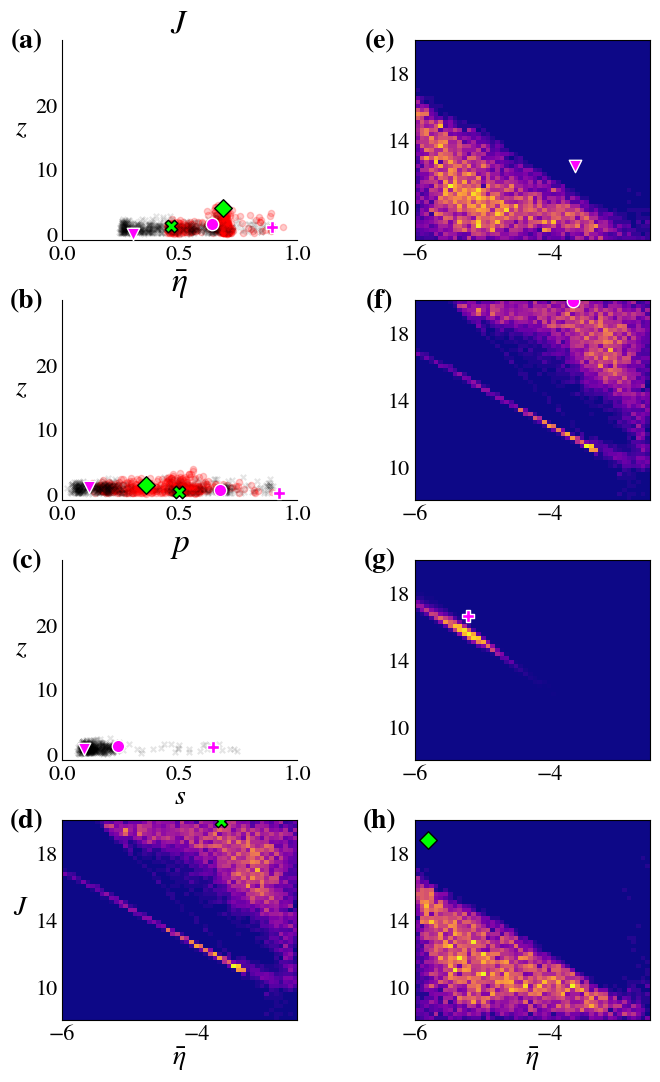

In [41]:
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['font.size']=20
matplotlib.rcParams['xtick.labelsize']=16
matplotlib.rcParams['ytick.labelsize']=16
matplotlib.rcParams['ytick.labelsize']=16
plt.style.use('_mpl-gallery')
networks = np.array([name.split('_')[1] for name in names[:50]])[names_idx[:7]]
fig = plt.figure(figsize=(6,10))
grid = GridSpec(ncols=2, nrows=4, figure=fig)
ax1 = fig.add_subplot(grid[0,0])
ax2 = fig.add_subplot(grid[1,0], sharex=ax1, sharey=ax1)
ax3 = fig.add_subplot(grid[2,0], sharex=ax1, sharey=ax1)
axes = np.array([ax1, ax2, ax3])

# grid = GridSpec(ncols=3, nrows=3, figure=fig)
# axes = np.array([fig.add_subplot(grid[i,:]) for i in range(0,3)])
GT_mpr = np.load('gt_mpr_homogeneous_fixed_g_v3.npy')
# GT_mlp_fixed_p = np.load('gt_mlp_fixed_p_homogeneous_fixed_g_v2.npy')
GT_mlp_qif = np.load('gt_mlp_qif_homogeneous_fixed_g_v3.npy')
ss = []
zz = []
axes_left = []
axes_right = []
for j, (MAPS, GT, name) in enumerate(zip([MAPS_mlp_qif, MAPS_crossed], [GT_mlp_qif, GT_mlp_qif], ['a', 'b', 'c', 'd'])):
    n = 3 if j==0 else 2
    for ax, i in zip(axes, range(n)):
        MAPS = np.array(MAPS)
        mu = np.mean(MAPS[:,:,i], axis=1)
        var = np.var(MAPS[:,:,i], axis=1)
        z = np.abs((mu-GT[:,i])/np.sqrt(var))
        zz.append(z)
        match i:
            case 0:
                var_prior = (1/12)*(20-8)**2
            case 1:
                var_prior = (1/12)*(-6+2.5)**2
            case 2:
                var_prior = (1/12)*(1-.6)**2
        s = 1-(var/np.repeat(var_prior, len(var)).reshape(var.shape))
        ss.append(s)

        if j==0:
            ax.scatter(x=s, y=z, c='k', s=15, cmap='viridis', alpha=.1, marker='x')
        else:
            ax.scatter(x=s, y=z, c='r', s=20, cmap='viridis',  alpha=.2, facecolors='none', edgecolors='r', zorder=-1000)
        ax.set_xlim([0,1])
        ax.set_ylim([-1,30])
        ax.set_yticks([0,10,20], [0,10,20])
        ax.grid(False)
        ax.spines[['right', 'top']].set_visible(False)
        net = networks[i][:3]

    if j==1:
        selection = np.argwhere((ss[3]<0.8) & (zz[3]>1))
        ax_ = fig.add_subplot(grid[3,0])
        x, y = np.array(MAPS_crossed)[selection,:,:].squeeze()[0].T
        ax_.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
        ax_.scatter(GT_mlp_qif[selection,1][0], GT_mlp_qif[selection,0][0], s=80, c='lime',marker='X', zorder=2000, edgecolors='k', linewidth=1)
        ax1.scatter(ss[3][selection][0], zz[3][selection][0], s=80, c='lime',marker='X', zorder=2000, edgecolors='k', linewidth=1)
        ax2.scatter(ss[4][selection][0], zz[4][selection][0], s=80, c='lime',marker='X', zorder=2000, edgecolors='k', linewidth=1)
        ax_.grid(False)
        axes_left.append(ax_)

        selection = np.argwhere((ss[3]>0.5) & (zz[3]>2))
        ax_ = fig.add_subplot(grid[3,1])
        x, y = np.array(MAPS_crossed)[selection,:,:].squeeze()[0].T
        ax_.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
        ax_.scatter(GT_mlp_qif[selection,1][0], GT_mlp_qif[selection,0][0], s=80, c='lime',marker='D', zorder=2000, edgecolors='k', linewidth=1)
        ax1.scatter(ss[3][selection][0], zz[3][selection][0], s=80, c='lime',marker='D', zorder=2000, edgecolors='k', linewidth=1)
        ax2.scatter(ss[4][selection][0], zz[4][selection][0], s=80, c='lime',marker='D', zorder=2000, edgecolors='k', linewidth=1)
        ax_.grid(False)
        axes_left.append(ax_)

        selection = np.argwhere((ss[0]<0.4) & (zz[1]<1))
        ax_ = fig.add_subplot(grid[0,1])
        x, y = np.array(MAPS_crossed)[selection,:,:].squeeze()[0].T
        ax_.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
        ax_.scatter(GT_mlp_qif[selection,1][0], GT_mlp_qif[selection,0][0], s=80, c='fuchsia',marker='v', zorder=2000, edgecolors='w', linewidth=1)
        ax1.scatter(ss[0][selection][0], zz[0][selection][0], s=80, c='fuchsia',marker='v', zorder=2000, edgecolors='w', linewidth=1)
        ax2.scatter(ss[1][selection][0], zz[1][selection][0], s=80, c='fuchsia',marker='v', zorder=2000, edgecolors='w', linewidth=1)
        ax3.scatter(ss[2][selection][0], zz[2][selection][0], s=80, c='fuchsia',marker='v', zorder=2000, edgecolors='w', linewidth=1)
        ax_.grid(False)
        axes_right.append(ax_)

        selection = np.argwhere((ss[0]>0.6) & (ss[0]<0.8))
        h = 0
        ax_ = fig.add_subplot(grid[1,1])
        x, y = np.array(MAPS_crossed)[selection,:,:].squeeze()[0].T
        ax_.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
        ax_.scatter(GT_mlp_qif[selection,1][h], GT_mlp_qif[selection,0][h], s=80, c='fuchsia',marker='o', zorder=2000, edgecolors='w', linewidth=1)
        ax1.scatter(ss[0][selection][h], zz[0][selection][h], s=80, c='fuchsia',marker='o', zorder=2000, edgecolors='w', linewidth=1)
        ax2.scatter(ss[1][selection][0], zz[1][selection][0], s=80, c='fuchsia',marker='o', zorder=2000, edgecolors='w', linewidth=1)
        ax3.scatter(ss[2][selection][0], zz[2][selection][0], s=80, c='fuchsia',marker='o', zorder=2000, edgecolors='w', linewidth=1)
        ax_.grid(False)
        axes_right.append(ax_)


        selection = np.argwhere((ss[2]>0.6) & (zz[1]<2))
        h = 0
        ax_ = fig.add_subplot(grid[2,1])
        x, y = np.array(MAPS_crossed)[selection,:,:].squeeze()[0].T
        ax_.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
        ax_.scatter(GT_mlp_qif[selection,1][h], GT_mlp_qif[selection,0][h], s=80, c='fuchsia',marker='P', zorder=2000, edgecolors='w', linewidth=1)
        ax1.scatter(ss[0][selection][h], zz[0][selection][h], s=80, c='fuchsia',marker='P', zorder=2000, edgecolors='w', linewidth=1)
        ax2.scatter(ss[1][selection][0], zz[1][selection][0], s=80, c='fuchsia',marker='P', zorder=2000, edgecolors='w', linewidth=1)
        ax3.scatter(ss[2][selection][0], zz[2][selection][0], s=80, c='fuchsia',marker='P', zorder=2000, edgecolors='w', linewidth=1)
        ax_.grid(False)
        axes_right.append(ax_)
    [ax.set_ylabel(rf'$z$', rotation=0, labelpad=10) for ax in axes]
    # [ax.set_xlabel(rf'$s$', rotation=0, labelpad=0) for ax in axes]
    axes[0].set_title(r'$J$')
    axes[1].set_title(r'$\bar{\eta}$')
    axes[2].set_title(r'$p$')
    axes[2].set_xlabel(rf'$s$', rotation=0, labelpad=0)

letters = ['(a)', '(b)', '(c)', '(d)']
[ax.annotate(letters[i], xy=(-.15, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold') for i, ax in enumerate(fig.axes[:4])]
letters = ['(e)', '(f)', '(g)', '(h)']
[ax.annotate(letters[i], xy=(-.15, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold') for i, ax in enumerate(axes_right+[axes_left[1]])]
# axes_left[0].set_xlabel(rf'$\eta$', rotation=0, labelpad=0)
axes_left[0].set_ylabel(r'$J$', rotation=0, labelpad=10)
# [ax.set_ylabel(rf'$J$', rotation=0) for ax in axes_left]
[ax.set_xlabel(r'$\bar{\eta}$', rotation=0, labelpad=0) for ax in axes_left]
[ax.set_yticks([10, 14, 18], [10, 14, 18]) for ax in axes_left]
[ax.set_yticks([10, 14, 18], [10, 14, 18]) for ax in axes_right]
# [ax.set_yticks([]) for ax in axes_right]
plt.subplots_adjust(wspace=.5, hspace=.3)
# fig.savefig('paper_figs/inference_comp_stat.png', dpi=600, facecolor='None', bbox_inches='tight')
plt.show()



/var/folders/ht/k1bq940j1nzdxy0vc8gf2_d40000gn/T/ipykernel_1033/2418482748.py:44: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x=s, y=z, c='k', s=15, cmap='viridis', alpha=.1, marker='x')
/var/folders/ht/k1bq940j1nzdxy0vc8gf2_d40000gn/T/ipykernel_1033/2418482748.py:44: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x=s, y=z, c='k', s=15, cmap='viridis', alpha=.1, marker='x')
/var/folders/ht/k1bq940j1nzdxy0vc8gf2_d40000gn/T/ipykernel_1033/2418482748.py:44: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x=s, y=z, c='k', s=15, cmap='viridis', alpha=.1, marker='x')
/var/folders/ht/k1bq940j1nzdxy0vc8gf2_d40000gn/T/ipykernel_1033/2418482748.py:46: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x=s, y=z, c='r', s=20, cmap='viridis',  alpha=.2, facecolors='none', edgecolo

IndexError: index 0 is out of bounds for axis 0 with size 0

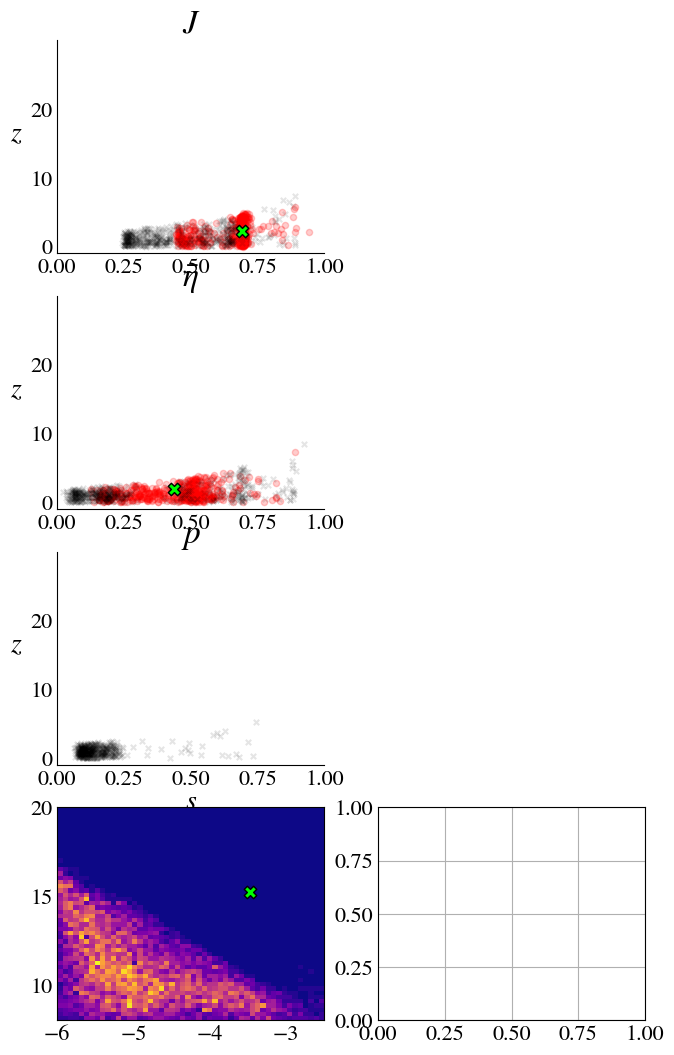

In [38]:
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['font.size']=20
matplotlib.rcParams['xtick.labelsize']=16
matplotlib.rcParams['ytick.labelsize']=16
matplotlib.rcParams['ytick.labelsize']=16
plt.style.use('_mpl-gallery')
networks = np.array([name.split('_')[1] for name in names[:50]])[names_idx[:7]]
fig = plt.figure(figsize=(6,10))
grid = GridSpec(ncols=2, nrows=4, figure=fig)
ax1 = fig.add_subplot(grid[0,0])
ax2 = fig.add_subplot(grid[1,0], sharex=ax1, sharey=ax1)
ax3 = fig.add_subplot(grid[2,0], sharex=ax1, sharey=ax1)
axes = np.array([ax1, ax2, ax3])

# grid = GridSpec(ncols=3, nrows=3, figure=fig)
# axes = np.array([fig.add_subplot(grid[i,:]) for i in range(0,3)])
GT_mpr = np.load('gt_mpr_homogeneous_fixed_g_v2.npy')
GT_mlp_fixed_p = np.load('gt_mlp_fixed_p_homogeneous_fixed_g_v2.npy')
GT_mlp_qif = np.load('gt_mlp_qif_homogeneous_fixed_g_v2.npy')
ss = []
zz = []
axes_left = []
axes_right = []
for j, (MAPS, GT, name) in enumerate(zip([MAPS_mlp_qif, MAPS_crossed], [GT_mlp_qif, GT_mlp_qif], ['a', 'b', 'c', 'd'])):
    n = 3 if j==0 else 2
    for ax, i in zip(axes, range(n)):
        MAPS = np.array(MAPS)
        mu = np.mean(MAPS[:,:,i], axis=1)
        var = np.var(MAPS[:,:,i], axis=1)
        z = np.abs((mu-GT[:,i])/np.sqrt(var))
        zz.append(z)
        match i:
            case 0:
                var_prior = (1/12)*(20-8)**2
            case 1:
                var_prior = (1/12)*(-6+2.5)**2
            case 2:
                var_prior = (1/12)*(1-.6)**2
        s = 1-(var/np.repeat(var_prior, len(var)).reshape(var.shape))
        ss.append(s)

        if j==0:
            ax.scatter(x=s, y=z, c='k', s=15, cmap='viridis', alpha=.1, marker='x')
        else:
            ax.scatter(x=s, y=z, c='r', s=20, cmap='viridis',  alpha=.2, facecolors='none', edgecolors='r', zorder=-1000)
        ax.set_xlim([0,1])
        ax.set_ylim([-1,30])
        ax.set_yticks([0,10,20], [0,10,20])
        ax.grid(False)
        ax.spines[['right', 'top']].set_visible(False)
        net = networks[i][:3]

    if j==1:
        selection = np.argwhere((ss[3]<0.8) & (zz[3]>1))
        ax_ = fig.add_subplot(grid[3,0])
        x, y = np.array(MAPS_crossed)[selection,:,:].squeeze()[0].T
        ax_.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
        ax_.scatter(GT_mlp_qif[selection,1][0], GT_mlp_qif[selection,0][0], s=80, c='lime',marker='X', zorder=2000, edgecolors='k', linewidth=1)
        ax1.scatter(ss[3][selection][0], zz[3][selection][0], s=80, c='lime',marker='X', zorder=2000, edgecolors='k', linewidth=1)
        ax2.scatter(ss[4][selection][0], zz[4][selection][0], s=80, c='lime',marker='X', zorder=2000, edgecolors='k', linewidth=1)
        ax_.grid(False)
        axes_left.append(ax_)

        selection = np.argwhere((ss[3]>0.9) & (zz[3]>8))
        ax_ = fig.add_subplot(grid[3,1])
        x, y = np.array(MAPS_crossed)[selection,:,:].squeeze()[0].T
        ax_.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
        ax_.scatter(GT_mlp_qif[selection,1][0], GT_mlp_qif[selection,0][0], s=80, c='lime',marker='D', zorder=2000, edgecolors='k', linewidth=1)
        ax1.scatter(ss[3][selection][0], zz[3][selection][0], s=80, c='lime',marker='D', zorder=2000, edgecolors='k', linewidth=1)
        ax2.scatter(ss[4][selection][0], zz[4][selection][0], s=80, c='lime',marker='D', zorder=2000, edgecolors='k', linewidth=1)
        ax_.grid(False)
        axes_left.append(ax_)

        selection = np.argwhere((ss[0]<0.4) & (zz[1]<1))
        ax_ = fig.add_subplot(grid[0,1])
        x, y = np.array(MAPS_crossed)[selection,:,:].squeeze()[0].T
        ax_.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
        ax_.scatter(GT_mlp_qif[selection,1][0], GT_mlp_qif[selection,0][0], s=80, c='fuchsia',marker='v', zorder=2000, edgecolors='w', linewidth=1)
        ax1.scatter(ss[0][selection][0], zz[0][selection][0], s=80, c='fuchsia',marker='v', zorder=2000, edgecolors='w', linewidth=1)
        ax2.scatter(ss[1][selection][0], zz[1][selection][0], s=80, c='fuchsia',marker='v', zorder=2000, edgecolors='w', linewidth=1)
        ax3.scatter(ss[2][selection][0], zz[2][selection][0], s=80, c='fuchsia',marker='v', zorder=2000, edgecolors='w', linewidth=1)
        ax_.grid(False)
        axes_right.append(ax_)

        selection = np.argwhere((ss[0]>0.6) & (ss[0]<0.8))
        h = 0
        ax_ = fig.add_subplot(grid[1,1])
        x, y = np.array(MAPS_crossed)[selection,:,:].squeeze()[0].T
        ax_.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
        ax_.scatter(GT_mlp_qif[selection,1][h], GT_mlp_qif[selection,0][h], s=80, c='fuchsia',marker='o', zorder=2000, edgecolors='w', linewidth=1)
        ax1.scatter(ss[0][selection][h], zz[0][selection][h], s=80, c='fuchsia',marker='o', zorder=2000, edgecolors='w', linewidth=1)
        ax2.scatter(ss[1][selection][0], zz[1][selection][0], s=80, c='fuchsia',marker='o', zorder=2000, edgecolors='w', linewidth=1)
        ax3.scatter(ss[2][selection][0], zz[2][selection][0], s=80, c='fuchsia',marker='o', zorder=2000, edgecolors='w', linewidth=1)
        ax_.grid(False)
        axes_right.append(ax_)


        selection = np.argwhere((ss[2]>0.6) & (zz[1]<2))
        h = 0
        ax_ = fig.add_subplot(grid[2,1])
        x, y = np.array(MAPS_crossed)[selection,:,:].squeeze()[0].T
        ax_.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
        ax_.scatter(GT_mlp_qif[selection,1][h], GT_mlp_qif[selection,0][h], s=80, c='fuchsia',marker='P', zorder=2000, edgecolors='w', linewidth=1)
        ax1.scatter(ss[0][selection][h], zz[0][selection][h], s=80, c='fuchsia',marker='P', zorder=2000, edgecolors='w', linewidth=1)
        ax2.scatter(ss[1][selection][0], zz[1][selection][0], s=80, c='fuchsia',marker='P', zorder=2000, edgecolors='w', linewidth=1)
        ax3.scatter(ss[2][selection][0], zz[2][selection][0], s=80, c='fuchsia',marker='P', zorder=2000, edgecolors='w', linewidth=1)
        ax_.grid(False)
        axes_right.append(ax_)
    [ax.set_ylabel(rf'$z$', rotation=0, labelpad=10) for ax in axes]
    # [ax.set_xlabel(rf'$s$', rotation=0, labelpad=0) for ax in axes]
    axes[0].set_title(r'$J$')
    axes[1].set_title(r'$\bar{\eta}$')
    axes[2].set_title(r'$p$')
    axes[2].set_xlabel(rf'$s$', rotation=0, labelpad=0)

letters = ['(a)', '(b)', '(c)', '(d)']
[ax.annotate(letters[i], xy=(-.15, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold') for i, ax in enumerate(fig.axes[:4])]
letters = ['(e)', '(f)', '(g)', '(h)']
[ax.annotate(letters[i], xy=(-.15, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold') for i, ax in enumerate(axes_right+[axes_left[1]])]
# axes_left[0].set_xlabel(rf'$\eta$', rotation=0, labelpad=0)
axes_left[0].set_ylabel(r'$J$', rotation=0, labelpad=10)
# [ax.set_ylabel(rf'$J$', rotation=0) for ax in axes_left]
[ax.set_xlabel(r'$\bar{\eta}$', rotation=0, labelpad=0) for ax in axes_left]
[ax.set_yticks([10, 14, 18], [10, 14, 18]) for ax in axes_left]
[ax.set_yticks([10, 14, 18], [10, 14, 18]) for ax in axes_right]
# [ax.set_yticks([]) for ax in axes_right]
plt.subplots_adjust(wspace=.5, hspace=.3)
fig.savefig('paper_figs/inference_comp_stat.png', dpi=600, facecolor='None', bbox_inches='tight')
plt.show()



/var/folders/ht/k1bq940j1nzdxy0vc8gf2_d40000gn/T/ipykernel_68485/4073235421.py:44: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x=s, y=z, c='k', s=15, cmap='viridis', alpha=.1, marker='x')
/var/folders/ht/k1bq940j1nzdxy0vc8gf2_d40000gn/T/ipykernel_68485/4073235421.py:44: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x=s, y=z, c='k', s=15, cmap='viridis', alpha=.1, marker='x')
/var/folders/ht/k1bq940j1nzdxy0vc8gf2_d40000gn/T/ipykernel_68485/4073235421.py:44: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x=s, y=z, c='k', s=15, cmap='viridis', alpha=.1, marker='x')
/var/folders/ht/k1bq940j1nzdxy0vc8gf2_d40000gn/T/ipykernel_68485/4073235421.py:46: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x=s, y=z, c='r', s=20, cmap='viridis',  alpha=.2, facecolors='none', edge

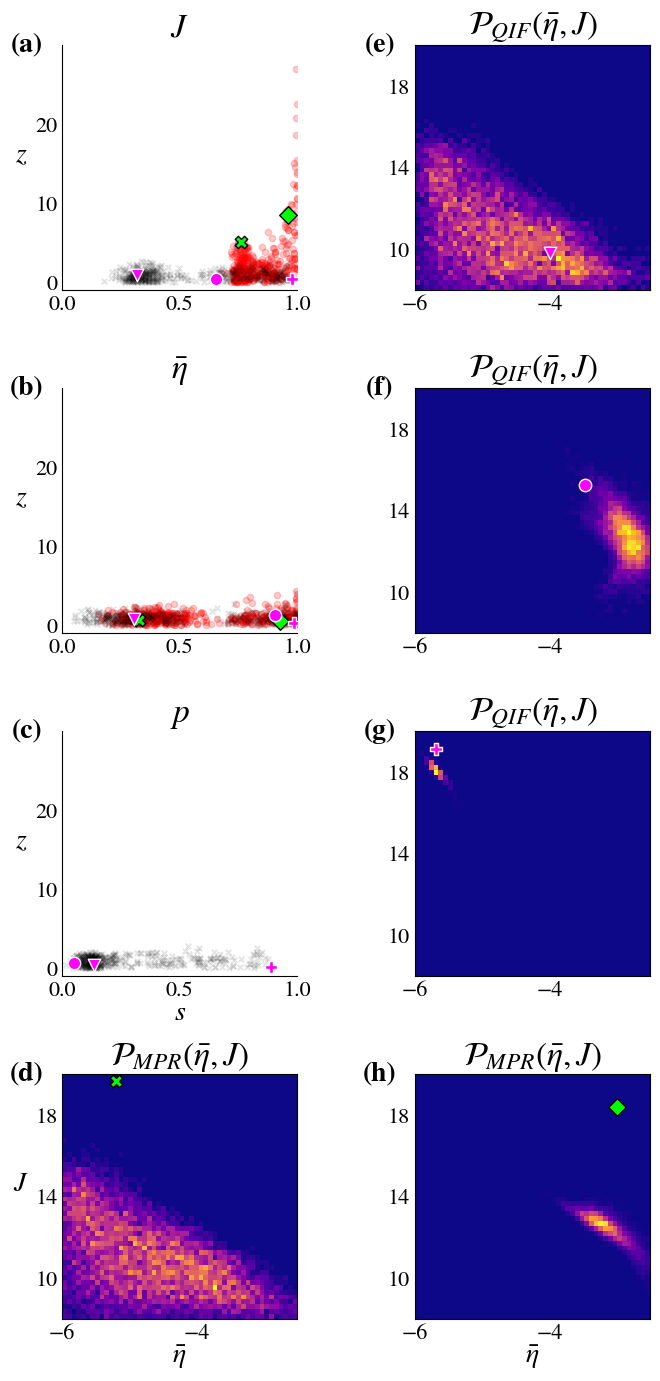

In [127]:
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['font.size']=20
matplotlib.rcParams['xtick.labelsize']=16
matplotlib.rcParams['ytick.labelsize']=16
matplotlib.rcParams['ytick.labelsize']=16
plt.style.use('_mpl-gallery')
networks = np.array([name.split('_')[1] for name in names[:50]])[names_idx[:7]]
fig = plt.figure(figsize=(6,13))
grid = GridSpec(ncols=2, nrows=4, figure=fig)
ax1 = fig.add_subplot(grid[0,0])
ax2 = fig.add_subplot(grid[1,0], sharex=ax1, sharey=ax1)
ax3 = fig.add_subplot(grid[2,0], sharex=ax1, sharey=ax1)
axes = np.array([ax1, ax2, ax3])

# grid = GridSpec(ncols=3, nrows=3, figure=fig)
# axes = np.array([fig.add_subplot(grid[i,:]) for i in range(0,3)])
GT_mpr = np.load('gt_mpr_homogeneous_fixed_g_v2.npy')
GT_mlp_fixed_p = np.load('gt_mlp_fixed_p_homogeneous_fixed_g_v2.npy')
GT_mlp_qif = np.load('gt_mlp_qif_homogeneous_fixed_g_v2.npy')
ss = []
zz = []
axes_left = []
axes_right = []
for j, (MAPS, GT, name) in enumerate(zip([MAPS_mlp_qif, MAPS_crossed], [GT_mlp_qif, GT_mlp_qif], ['a', 'b', 'c', 'd'])):
    n = 3 if j==0 else 2
    for ax, i in zip(axes, range(n)):
        MAPS = np.array(MAPS)
        mu = np.mean(MAPS[:,:,i], axis=1)
        var = np.var(MAPS[:,:,i], axis=1)
        z = np.abs((mu-GT[:,i])/np.sqrt(var))
        zz.append(z)
        match i:
            case 0:
                var_prior = (1/12)*(20-8)**2
            case 1:
                var_prior = (1/12)*(-6+2.5)**2
            case 2:
                var_prior = (1/12)*(1-.6)**2
        s = 1-(var/np.repeat(var_prior, len(var)).reshape(var.shape))
        ss.append(s)

        if j==0:
            ax.scatter(x=s, y=z, c='k', s=15, cmap='viridis', alpha=.1, marker='x')
        else:
            ax.scatter(x=s, y=z, c='r', s=20, cmap='viridis',  alpha=.2, facecolors='none', edgecolors='r', zorder=-1000)
        ax.set_xlim([0,1])
        ax.set_ylim([-1,30])
        ax.set_yticks([0,10,20], [0,10,20])
        ax.grid(False)
        ax.spines[['right', 'top']].set_visible(False)
        net = networks[i][:3]

    if j==1:
        selection = np.argwhere((ss[3]<0.8) & (zz[3]>5))
        ax_ = fig.add_subplot(grid[3,0])
        x, y = np.array(MAPS_crossed)[selection,:,:].squeeze()[0].T
        ax_.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
        ax_.scatter(GT_mlp_qif[selection,1][0], GT_mlp_qif[selection,0][0], s=80, c='lime',marker='X', zorder=2000, edgecolors='k', linewidth=1)
        ax1.scatter(ss[3][selection][0], zz[3][selection][0], s=80, c='lime',marker='X', zorder=2000, edgecolors='k', linewidth=1)
        ax2.scatter(ss[4][selection][0], zz[4][selection][0], s=80, c='lime',marker='X', zorder=2000, edgecolors='k', linewidth=1)
        ax_.grid(False)
        axes_left.append(ax_)

        selection = np.argwhere((ss[3]>0.9) & (zz[3]>8))
        ax_ = fig.add_subplot(grid[3,1])
        x, y = np.array(MAPS_crossed)[selection,:,:].squeeze()[0].T
        ax_.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
        ax_.scatter(GT_mlp_qif[selection,1][0], GT_mlp_qif[selection,0][0], s=80, c='lime',marker='D', zorder=2000, edgecolors='k', linewidth=1)
        ax1.scatter(ss[3][selection][0], zz[3][selection][0], s=80, c='lime',marker='D', zorder=2000, edgecolors='k', linewidth=1)
        ax2.scatter(ss[4][selection][0], zz[4][selection][0], s=80, c='lime',marker='D', zorder=2000, edgecolors='k', linewidth=1)
        ax_.grid(False)
        axes_left.append(ax_)

        selection = np.argwhere((ss[0]<0.4) & (zz[1]<1))
        ax_ = fig.add_subplot(grid[0,1])
        x, y = np.array(MAPS_crossed)[selection,:,:].squeeze()[0].T
        ax_.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
        ax_.scatter(GT_mlp_qif[selection,1][0], GT_mlp_qif[selection,0][0], s=80, c='fuchsia',marker='v', zorder=2000, edgecolors='w', linewidth=1)
        ax1.scatter(ss[0][selection][0], zz[0][selection][0], s=80, c='fuchsia',marker='v', zorder=2000, edgecolors='w', linewidth=1)
        ax2.scatter(ss[1][selection][0], zz[1][selection][0], s=80, c='fuchsia',marker='v', zorder=2000, edgecolors='w', linewidth=1)
        ax3.scatter(ss[2][selection][0], zz[2][selection][0], s=80, c='fuchsia',marker='v', zorder=2000, edgecolors='w', linewidth=1)
        ax_.grid(False)
        axes_right.append(ax_)

        selection = np.argwhere((ss[0]>0.6) & (ss[0]<0.8))
        h = 0
        ax_ = fig.add_subplot(grid[1,1])
        x, y = np.array(MAPS_crossed)[selection,:,:].squeeze()[0].T
        ax_.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
        ax_.scatter(GT_mlp_qif[selection,1][h], GT_mlp_qif[selection,0][h], s=80, c='fuchsia',marker='o', zorder=2000, edgecolors='w', linewidth=1)
        ax1.scatter(ss[0][selection][h], zz[0][selection][h], s=80, c='fuchsia',marker='o', zorder=2000, edgecolors='w', linewidth=1)
        ax2.scatter(ss[1][selection][0], zz[1][selection][0], s=80, c='fuchsia',marker='o', zorder=2000, edgecolors='w', linewidth=1)
        ax3.scatter(ss[2][selection][0], zz[2][selection][0], s=80, c='fuchsia',marker='o', zorder=2000, edgecolors='w', linewidth=1)
        ax_.grid(False)
        axes_right.append(ax_)


        selection = np.argwhere((ss[2]>0.6) & (zz[1]<2))
        h = 0
        ax_ = fig.add_subplot(grid[2,1])
        x, y = np.array(MAPS_crossed)[selection,:,:].squeeze()[0].T
        ax_.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
        ax_.scatter(GT_mlp_qif[selection,1][h], GT_mlp_qif[selection,0][h], s=80, c='fuchsia',marker='P', zorder=2000, edgecolors='w', linewidth=1)
        ax1.scatter(ss[0][selection][h], zz[0][selection][h], s=80, c='fuchsia',marker='P', zorder=2000, edgecolors='w', linewidth=1)
        ax2.scatter(ss[1][selection][0], zz[1][selection][0], s=80, c='fuchsia',marker='P', zorder=2000, edgecolors='w', linewidth=1)
        ax3.scatter(ss[2][selection][0], zz[2][selection][0], s=80, c='fuchsia',marker='P', zorder=2000, edgecolors='w', linewidth=1)
        ax_.grid(False)
        axes_right.append(ax_)
    [ax.set_ylabel(rf'$z$', rotation=0, labelpad=10) for ax in axes]
    # [ax.set_xlabel(rf'$s$', rotation=0, labelpad=0) for ax in axes]
    axes[0].set_title(r'$J$')
    axes[1].set_title(r'$\bar{\eta}$')
    axes[2].set_title(r'$p$')
    axes[2].set_xlabel(rf'$s$', rotation=0, labelpad=0)

letters = ['(a)', '(b)', '(c)', '(d)']
[ax.annotate(letters[i], xy=(-.15, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold') for i, ax in enumerate(fig.axes[:4])]
letters = ['(e)', '(f)', '(g)', '(h)']
[ax.annotate(letters[i], xy=(-.15, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold') for i, ax in enumerate(axes_right+[axes_left[1]])]
# axes_left[0].set_xlabel(rf'$\eta$', rotation=0, labelpad=0)
axes_left[0].set_ylabel(r'$J$', rotation=0, labelpad=10)
# [ax.set_ylabel(rf'$J$', rotation=0) for ax in axes_left]
[ax.set_xlabel(r'$\bar{\eta}$', rotation=0, labelpad=0) for ax in axes_left]
[ax.set_title(r'$\mathcal{P}_{MPR}(\bar{\eta},J)$') for ax in axes_left]
[ax.set_title(r'$\mathcal{P}_{QIF}(\bar{\eta},J)$') for ax in axes_right]
[ax.set_yticks([10, 14, 18], [10, 14, 18]) for ax in axes_left]
[ax.set_yticks([10, 14, 18], [10, 14, 18]) for ax in axes_right]
# [ax.set_yticks([]) for ax in axes_right]
plt.subplots_adjust(wspace=.5, hspace=.4)
fig.savefig('paper_figs/inference_comp_stat.png', dpi=600, facecolor='None', bbox_inches='tight')
plt.show()



/var/folders/ht/k1bq940j1nzdxy0vc8gf2_d40000gn/T/ipykernel_68485/2832169770.py:44: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x=s, y=z, c='k', s=15, cmap='viridis', alpha=.1, marker='x')
/var/folders/ht/k1bq940j1nzdxy0vc8gf2_d40000gn/T/ipykernel_68485/2832169770.py:44: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x=s, y=z, c='k', s=15, cmap='viridis', alpha=.1, marker='x')
/var/folders/ht/k1bq940j1nzdxy0vc8gf2_d40000gn/T/ipykernel_68485/2832169770.py:44: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x=s, y=z, c='k', s=15, cmap='viridis', alpha=.1, marker='x')
/var/folders/ht/k1bq940j1nzdxy0vc8gf2_d40000gn/T/ipykernel_68485/2832169770.py:46: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x=s, y=z, c='r', s=20, cmap='viridis',  alpha=.2, facecolors='none', edge

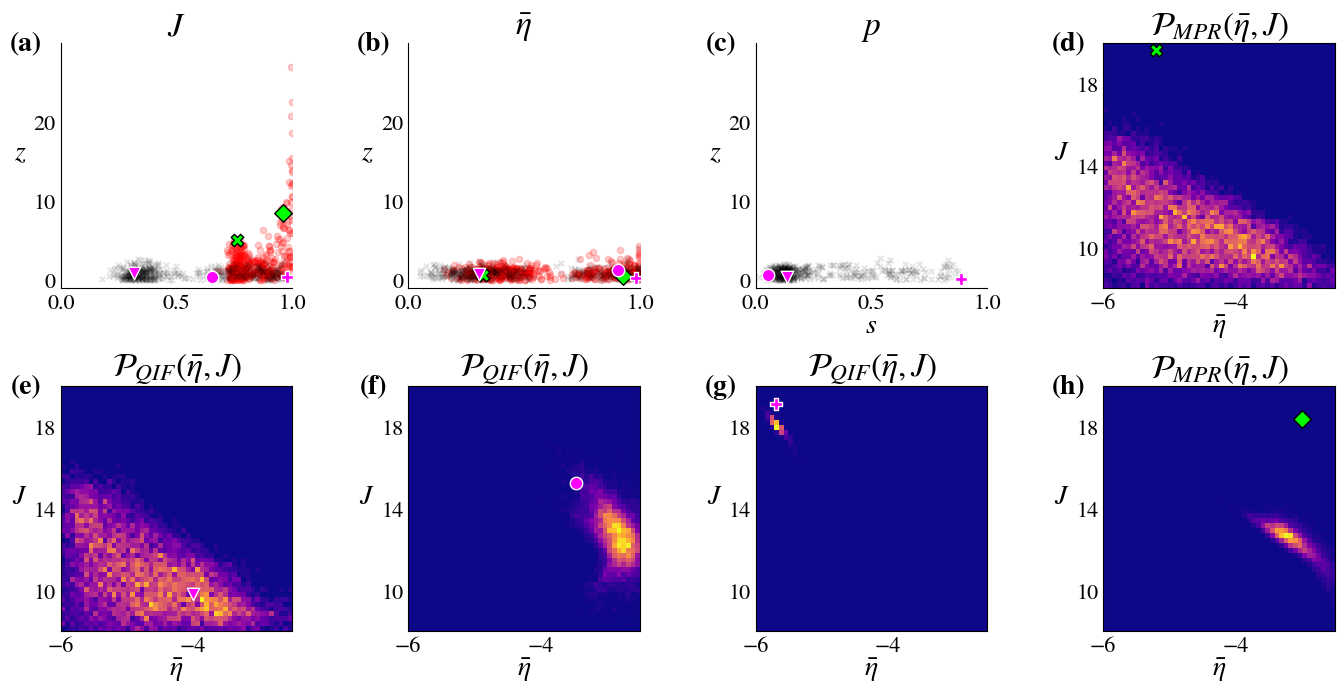

In [144]:
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['font.size']=20
matplotlib.rcParams['xtick.labelsize']=16
matplotlib.rcParams['ytick.labelsize']=16
matplotlib.rcParams['ytick.labelsize']=16
plt.style.use('_mpl-gallery')
networks = np.array([name.split('_')[1] for name in names[:50]])[names_idx[:7]]
fig = plt.figure(figsize=(13,6))
grid = GridSpec(ncols=4, nrows=2, figure=fig)
ax1 = fig.add_subplot(grid[0,0])
ax2 = fig.add_subplot(grid[0,1], sharex=ax1, sharey=ax1)
ax3 = fig.add_subplot(grid[0,2], sharex=ax1, sharey=ax1)
axes = np.array([ax1, ax2, ax3])

# grid = GridSpec(ncols=3, nrows=3, figure=fig)
# axes = np.array([fig.add_subplot(grid[i,:]) for i in range(0,3)])
GT_mpr = np.load('gt_mpr_homogeneous_fixed_g_v2.npy')
GT_mlp_fixed_p = np.load('gt_mlp_fixed_p_homogeneous_fixed_g_v2.npy')
GT_mlp_qif = np.load('gt_mlp_qif_homogeneous_fixed_g_v2.npy')
ss = []
zz = []
axes_left = []
axes_right = []
for j, (MAPS, GT, name) in enumerate(zip([MAPS_mlp_qif, MAPS_crossed], [GT_mlp_qif, GT_mlp_qif], ['a', 'b', 'c', 'd'])):
    n = 3 if j==0 else 2
    for ax, i in zip(axes, range(n)):
        MAPS = np.array(MAPS)
        mu = np.mean(MAPS[:,:,i], axis=1)
        var = np.var(MAPS[:,:,i], axis=1)
        z = np.abs((mu-GT[:,i])/np.sqrt(var))
        zz.append(z)
        match i:
            case 0:
                var_prior = (1/12)*(20-8)**2
            case 1:
                var_prior = (1/12)*(-6+2.5)**2
            case 2:
                var_prior = (1/12)*(1-.6)**2
        s = 1-(var/np.repeat(var_prior, len(var)).reshape(var.shape))
        ss.append(s)

        if j==0:
            ax.scatter(x=s, y=z, c='k', s=15, cmap='viridis', alpha=.1, marker='x')
        else:
            ax.scatter(x=s, y=z, c='r', s=20, cmap='viridis',  alpha=.2, facecolors='none', edgecolors='r', zorder=-1000)
        ax.set_xlim([0,1])
        ax.set_ylim([-1,30])
        ax.set_yticks([0,10,20], [0,10,20])
        ax.grid(False)
        ax.spines[['right', 'top']].set_visible(False)
        net = networks[i][:3]

    if j==1:
        selection = np.argwhere((ss[3]<0.8) & (zz[3]>5))
        ax_ = fig.add_subplot(grid[0,3])
        x, y = np.array(MAPS_crossed)[selection,:,:].squeeze()[0].T
        ax_.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
        ax_.scatter(GT_mlp_qif[selection,1][0], GT_mlp_qif[selection,0][0], s=80, c='lime',marker='X', zorder=2000, edgecolors='k', linewidth=1)
        ax1.scatter(ss[3][selection][0], zz[3][selection][0], s=80, c='lime',marker='X', zorder=2000, edgecolors='k', linewidth=1)
        ax2.scatter(ss[4][selection][0], zz[4][selection][0], s=80, c='lime',marker='X', zorder=2000, edgecolors='k', linewidth=1)
        ax_.grid(False)
        axes_left.append(ax_)

        selection = np.argwhere((ss[3]>0.9) & (zz[3]>8))
        ax_ = fig.add_subplot(grid[1,3])
        x, y = np.array(MAPS_crossed)[selection,:,:].squeeze()[0].T
        ax_.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
        ax_.scatter(GT_mlp_qif[selection,1][0], GT_mlp_qif[selection,0][0], s=80, c='lime',marker='D', zorder=2000, edgecolors='k', linewidth=1)
        ax1.scatter(ss[3][selection][0], zz[3][selection][0], s=80, c='lime',marker='D', zorder=2000, edgecolors='k', linewidth=1)
        ax2.scatter(ss[4][selection][0], zz[4][selection][0], s=80, c='lime',marker='D', zorder=2000, edgecolors='k', linewidth=1)
        ax_.grid(False)
        axes_left.append(ax_)

        selection = np.argwhere((ss[0]<0.4) & (zz[1]<1))
        ax_ = fig.add_subplot(grid[1,0])
        x, y = np.array(MAPS_crossed)[selection,:,:].squeeze()[0].T
        ax_.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
        ax_.scatter(GT_mlp_qif[selection,1][0], GT_mlp_qif[selection,0][0], s=80, c='fuchsia',marker='v', zorder=2000, edgecolors='w', linewidth=1)
        ax1.scatter(ss[0][selection][0], zz[0][selection][0], s=80, c='fuchsia',marker='v', zorder=2000, edgecolors='w', linewidth=1)
        ax2.scatter(ss[1][selection][0], zz[1][selection][0], s=80, c='fuchsia',marker='v', zorder=2000, edgecolors='w', linewidth=1)
        ax3.scatter(ss[2][selection][0], zz[2][selection][0], s=80, c='fuchsia',marker='v', zorder=2000, edgecolors='w', linewidth=1)
        ax_.grid(False)
        axes_right.append(ax_)

        selection = np.argwhere((ss[0]>0.6) & (ss[0]<0.8))
        h = 0
        ax_ = fig.add_subplot(grid[1,1])
        x, y = np.array(MAPS_crossed)[selection,:,:].squeeze()[0].T
        ax_.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
        ax_.scatter(GT_mlp_qif[selection,1][h], GT_mlp_qif[selection,0][h], s=80, c='fuchsia',marker='o', zorder=2000, edgecolors='w', linewidth=1)
        ax1.scatter(ss[0][selection][h], zz[0][selection][h], s=80, c='fuchsia',marker='o', zorder=2000, edgecolors='w', linewidth=1)
        ax2.scatter(ss[1][selection][0], zz[1][selection][0], s=80, c='fuchsia',marker='o', zorder=2000, edgecolors='w', linewidth=1)
        ax3.scatter(ss[2][selection][0], zz[2][selection][0], s=80, c='fuchsia',marker='o', zorder=2000, edgecolors='w', linewidth=1)
        ax_.grid(False)
        axes_right.append(ax_)


        selection = np.argwhere((ss[2]>0.6) & (zz[1]<2))
        h = 0
        ax_ = fig.add_subplot(grid[1,2])
        x, y = np.array(MAPS_crossed)[selection,:,:].squeeze()[0].T
        ax_.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
        ax_.scatter(GT_mlp_qif[selection,1][h], GT_mlp_qif[selection,0][h], s=80, c='fuchsia',marker='P', zorder=2000, edgecolors='w', linewidth=1)
        ax1.scatter(ss[0][selection][h], zz[0][selection][h], s=80, c='fuchsia',marker='P', zorder=2000, edgecolors='w', linewidth=1)
        ax2.scatter(ss[1][selection][0], zz[1][selection][0], s=80, c='fuchsia',marker='P', zorder=2000, edgecolors='w', linewidth=1)
        ax3.scatter(ss[2][selection][0], zz[2][selection][0], s=80, c='fuchsia',marker='P', zorder=2000, edgecolors='w', linewidth=1)
        ax_.grid(False)
        axes_right.append(ax_)
    [ax.set_ylabel(rf'$z$', rotation=0, labelpad=10) for ax in axes]
    # [ax.set_xlabel(rf'$s$', rotation=0, labelpad=0) for ax in axes]
    axes[0].set_title(r'$J$')
    axes[1].set_title(r'$\bar{\eta}$')
    axes[2].set_title(r'$p$')
    axes[2].set_xlabel(rf'$s$', rotation=0, labelpad=0)

letters = ['(a)', '(b)', '(c)', '(d)']
[ax.annotate(letters[i], xy=(-.15, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold') for i, ax in enumerate(fig.axes[:4])]
letters = ['(e)', '(f)', '(g)', '(h)']
[ax.annotate(letters[i], xy=(-.15, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold') for i, ax in enumerate(axes_right+[axes_left[1]])]
# axes_left[0].set_xlabel(rf'$\eta$', rotation=0, labelpad=0)
axes_left[0].set_ylabel(r'$J$', rotation=0, labelpad=10)
[ax.set_ylabel(r'$J$', rotation=0, labelpad=10) for ax in axes_right]
[ax.set_ylabel(r'$J$', rotation=0, labelpad=10) for ax in axes_left]
# [ax.set_ylabel(rf'$J$', rotation=0) for ax in axes_left]
[ax.set_xlabel(r'$\bar{\eta}$', rotation=0, labelpad=0) for ax in axes_left]
[ax.set_xlabel(r'$\bar{\eta}$', rotation=0, labelpad=0) for ax in axes_right]
[ax.set_title(r'$\mathcal{P}_{MPR}(\bar{\eta},J)$') for ax in axes_left]
[ax.set_title(r'$\mathcal{P}_{QIF}(\bar{\eta},J)$') for ax in axes_right]
[ax.set_yticks([10, 14, 18], [10, 14, 18]) for ax in axes_left]
[ax.set_yticks([10, 14, 18], [10, 14, 18]) for ax in axes_right]
# [ax.set_yticks([]) for ax in axes_right]
plt.subplots_adjust(wspace=.5, hspace=.4)
fig.savefig('paper_figs/POSTER_inference_comp_stat.png', dpi=600, facecolor='None', bbox_inches='tight')
plt.show()



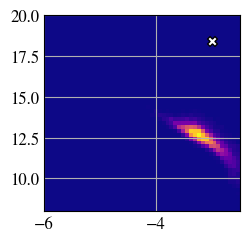

In [435]:
selection = np.argwhere((ss[3]>0.9) & (zz[3]>8))
x, y = np.array(MAPS_crossed)[selection,:,:].squeeze()[0].T
plt.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
plt.scatter(GT_mlp_qif[selection,1][0], GT_mlp_qif[selection,0][0], s=50, c='w',marker='X', zorder=2000, edgecolors='k', linewidth=1)

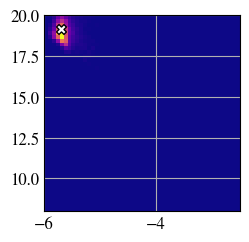

In [466]:
selection = np.argwhere((ss[0]>0.9) & (ss[1]>0.9))
x, y, z = np.array(MAPS_mlp_qif)[selection,:,:].squeeze()[0].T
plt.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
plt.scatter(GT_mlp_qif[selection,1][0], GT_mlp_qif[selection,0][0], s=50, c='w',marker='X', zorder=2000, edgecolors='k', linewidth=1)

In [472]:
selection = np.argwhere((ss[0]>0.9) & (zz[1]<1))

In [474]:
ss[0][2], zz[0][2]

(np.float64(0.9164982934792837), np.float64(0.3311257126797748))

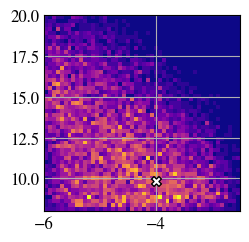

In [433]:
selection = np.argwhere((ss[0]<0.4) & (ss[1]<0.4))
x, y, z = np.array(MAPS_mlp_qif)[selection,:,:].squeeze()[0].T
plt.hist2d(y, x, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
plt.scatter(GT_mlp_qif[selection,1][0], GT_mlp_qif[selection,0][0], s=50, c='w',marker='X', zorder=2000, edgecolors='k', linewidth=1)

In [404]:
np.array(MAPS_mlp_qif).mean(axis=1)[np.argwhere((ss[0]<0.5) & (ss[1]<0.5))].shape

(282, 1, 3)

In [270]:
selection = np.argwhere(GT_mlp_qif[:,1]>=-5)

(338, 1)

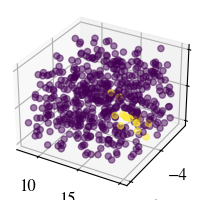

In [216]:
%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(GT_mlp_qif[:,0], GT_mlp_qif[:,1], GT_mlp_qif[:,2], alpha=.5, c=zz[2]>10, cmap='viridis')

In [66]:
# MAPS_mpr_to_mlp = []
# for i, gt in enumerate(GT_mpr):
#     print(f'{i}/{len(GT)}', end='\r')
#     with open('inference_mlp_fixed_p_homogeneous_fixed_g.pkl', 'rb') as f:
#         posterior = pickle.load(f)
#     posterior.set_default_x(gt[2:].astype('float32'))
#     rs = posterior.sample((10000,), show_progress_bars=False)
#     MAPS_mpr_to_mlp.append(rs)

In [67]:
# MAPS_mlp_to_mpr = []
# for i, gt in enumerate(GT_mlp_fixed_p):
#     print(f'{i}/{len(GT)}', end='\r')
#     with open('inference_mpr_homogeneous_fixed_g.pkl', 'rb') as f:
#         posterior = pickle.load(f)
#     posterior.set_default_x(gt[2:].astype('float32'))
#     rs = posterior.sample((10000,), show_progress_bars=False)
#     MAPS_mlp_to_mpr.append(rs)

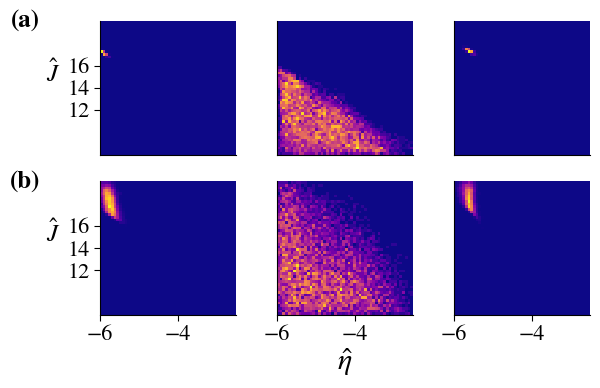

In [12]:
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['font.size']=18
matplotlib.rcParams['xtick.labelsize']=16
matplotlib.rcParams['ytick.labelsize']=16
plt.style.use('_mpl-gallery')
networks = np.array([name.split('_')[1] for name in names[:50]])[names_idx[:7]]
fig, axes = plt.subplots(2, 3, figsize=(5,3))
# grid = GridSpec(ncols=3, nrows=3, figure=fig)
# axes = np.array([fig.add_subplot(grid[i,:]) for i in range(0,3)])
for j, (axs, MAPS, GT, name) in enumerate(zip(axes, [MAPS_mpr, MAPS_mlp_qif_p1], [GT_mpr, GT_mpr], ['a', 'b', 'c'])):
    for ax, i, index in zip(axs, range(5), [12, 31, 73]):
        idx = np.argsort(np.array(GT)[:,1])
        GT = np.array(GT)[idx]
        MAPS = np.array(MAPS)[idx]
        x = MAPS[index,:,1]
        y = MAPS[index,:,0]
        ax.hist2d(x, y, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
        # ax.scatter(GT[index,1], GT[index,0], c='w', s=60, marker='X', zorder=2000, edgecolors='k', linewidth=1)
        ax.grid(False)
        ax.spines[['right', 'top']].set_visible(False)
        net = networks[i][:3]
        if i==0:
            ax.set_ylabel(rf'$\hat{{J}}$', rotation=0, labelpad=10)
            ax.set_yticks([12, 14, 16], [12, 14, 16])
        else:
            ax.set_ylabel('')
            ax.set_yticks([])
        if j==0:
            ax.set_xticks([])
        ax.tick_params(axis="y", direction='out', length=4)
        ax.tick_params(axis="x", direction='out', length=4)



axes[0,0].annotate('(a)', xy=(-0.55, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold')
axes[1,0].annotate('(b)', xy=(-0.55, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold')
fig.supxlabel(r'$\hat{\eta}$', y=-.2)
plt.subplots_adjust(wspace=.3, hspace=.2)
fig.savefig('paper_figs/inference_comp.png', dpi=600, facecolor='None', bbox_inches='tight')
plt.show()

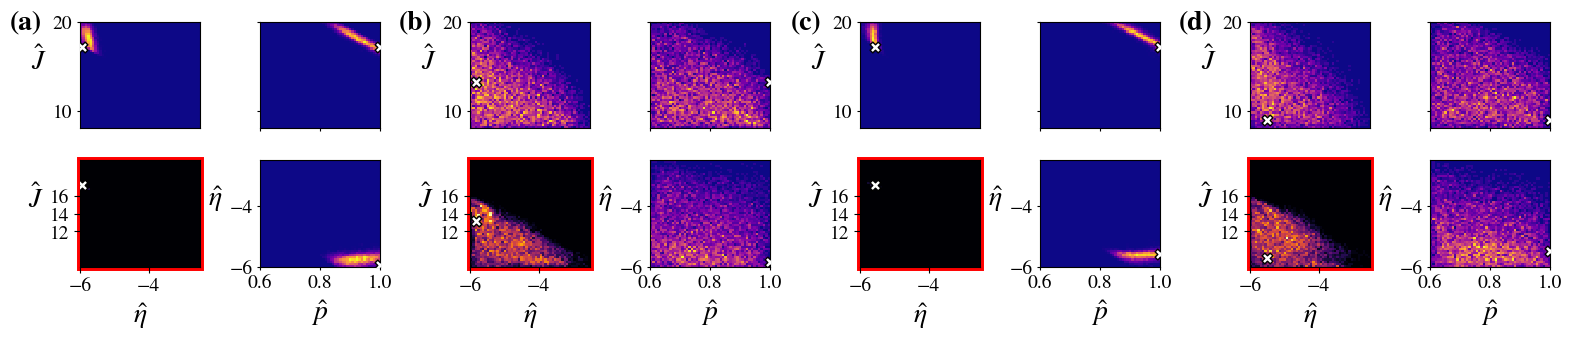

In [42]:
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['font.size']=20
matplotlib.rcParams['xtick.labelsize']=14
matplotlib.rcParams['ytick.labelsize']=14
plt.style.use('_mpl-gallery')
networks = np.array([name.split('_')[1] for name in names[:50]])[names_idx[:7]]
fig = plt.figure(constrained_layout=False, figsize=(15, 2.5))
grid = fig.add_gridspec(ncols=4, nrows=1, wspace=.3, hspace=.1)
from matplotlib.patches import Rectangle

GT_mpr = np.load('gt_mpr_homogeneous_fixed_g_v2.npy')
for i, index, letter in zip(range(4), [12, 31, 73, 90], ['(a)', '(b)', '(c)', '(d)']):
    subgrid = grid[i].subgridspec(2, 2, wspace=.5, hspace=.3)
    ax = fig.add_subplot(subgrid[1,0])
    ax1 = fig.add_subplot(subgrid[0,0])
    ax2 = fig.add_subplot(subgrid[0,1])
    ax3 = fig.add_subplot(subgrid[1,1])
    

    idx = np.argsort(np.array(GT_mpr)[:,1])
    GT = np.array(GT_mpr)[idx]
    MAPS = np.array(MAPS_mpr)[idx]
    x = MAPS[index,:,1]
    y = MAPS[index,:,0]
    ax.hist2d(x, y, bins=50, cmap='inferno', zorder=0, range=[[-6,-2.5],[8,20]])
    # ax.imshow(H[0], aspect="auto")
    ax.patch.set_edgecolor('red')
    ax.patch.set_linewidth(5)
    rec = Rectangle((ax.axis()[0]-.03,ax.axis()[2]-.05),(ax.axis()[1]-ax.axis()[0]+.03),(ax.axis()[3]-ax.axis()[2]),fill=False,lw=2, color='red')
    # rec = ax.add_patch(rec)
    rec.set_clip_on(False)
    ax.scatter(GT[index,1], GT[index,0], c='w', s=60, marker='X', zorder=2000, edgecolors='k', linewidth=1)
    ax.grid(False)
    ax.spines[['right', 'top']].set_visible(True)
    net = networks[i][:3]
    ax.set_ylabel(rf'$\hat{{J}}$', rotation=0, labelpad=10)
    ax.set_xlabel(r'$\hat{\eta}$')
    ax.set_yticks([12, 14, 16], [12, 14, 16])
    ax.tick_params(axis="y", direction='out', length=4)
    ax.tick_params(axis="x", direction='out', length=4)
    # ax.set_position([ax.get_position().x0+.01, ax.get_position().y0+.1, ax.get_position().width-.1, ax.get_position().height-.2])
    
    MAPS = np.array(MAPS_mlp_qif_p1)[idx]
    x = MAPS[index,:,1]
    y = MAPS[index,:,0]
    ax1.hist2d(x, y, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
    ax1.scatter(GT[index,1], GT[index,0], c='w', s=60, marker='X', zorder=2000, edgecolors='k', linewidth=1)
    ax1.grid(False)
    x = MAPS[index,:,2]
    y = MAPS[index,:,0]
    ax2.hist2d(x, y, bins=50, cmap='plasma', zorder=0, range=[[.6,1.],[8,20]])
    ax2.scatter(1., GT[index,0], c='w', s=60, marker='X', zorder=2000, edgecolors='k', linewidth=1)
    ax2.grid(False)
    x = MAPS[index,:,2]
    y = MAPS[index,:,1]
    ax3.hist2d(x, y, bins=50, cmap='plasma', zorder=0, range=[[.6,1.],[-6,-2.5]])
    ax3.scatter(1., GT[index,1], c='w', s=60, marker='X', zorder=2000, edgecolors='k', linewidth=1)
    ax3.grid(False)

    # ax1.set_xlabel(r'$\hat{\eta}$')
    ax1.set_xticks([])
    ax1.set_ylabel(r'$\hat{J}$', rotation=0,labelpad=10)
    # ax2.set_xlabel(r'$\hat{p}$')
    ax2.set_xticklabels([])
    ax2.set_yticklabels([])
    # ax2.set_ylabel(r'$\hat{J}$', rotation=0,labelpad=10)
    ax3.set_xlabel(r'$\hat{p}$')
    ax3.set_ylabel(r'$\hat{\eta}$', rotation=0,labelpad=10)
    
    [ax.tick_params(axis="y", direction='out', length=2) for ax in [ax1, ax2, ax3]]
    [ax.tick_params(axis="x", direction='out', length=2) for ax in [ax1, ax2, ax3]]


    ax1.annotate(letter, xy=(-0.45, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold')
# axs2[0].annotate('(b)', xy=(-0.55, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold')
# fig.supxlabel(r'$\hat{\eta}$', y=-.2)
# plt.subplots_adjust(wspace=.3, hspace=.2)
# fig.savefig('paper_figs/inference_comp_wih_p.png', dpi=600, facecolor='None', bbox_inches='tight')
plt.show()

In [164]:
GT_mlp_qif[idx][1,:3]

array([15.92222351, -5.93379488,  0.88568084])

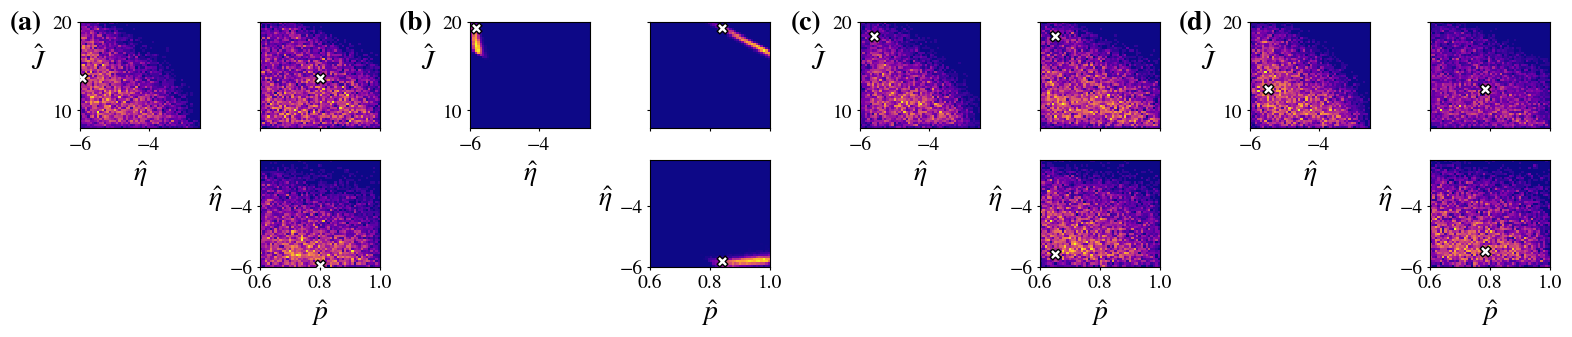

In [43]:
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['font.size']=20
matplotlib.rcParams['xtick.labelsize']=14
matplotlib.rcParams['ytick.labelsize']=14
plt.style.use('_mpl-gallery')
networks = np.array([name.split('_')[1] for name in names[:50]])[names_idx[:7]]
fig = plt.figure(constrained_layout=False, figsize=(15, 2.5))
grid = fig.add_gridspec(ncols=4, nrows=1, wspace=.3, hspace=.1)
from matplotlib.patches import Rectangle

GT_mlp_qif = np.load('gt_mlp_qif_homogeneous_fixed_g_v2.npy')
for i, index, letter in zip(range(4), [10, 31, 73, 90], ['(a)', '(b)', '(c)', '(d)']):
    subgrid = grid[i].subgridspec(2, 2, wspace=.5, hspace=.3)
    # ax = fig.add_subplot(subgrid[1,0])
    ax1 = fig.add_subplot(subgrid[0,0])
    ax2 = fig.add_subplot(subgrid[0,1])
    ax3 = fig.add_subplot(subgrid[1,1])
    

    idx = np.argsort(np.array(GT_mlp_qif)[:,1])
    GT = np.array(GT_mlp_qif)[idx]
    MAPS = np.array(MAPS_mlp_qif)[idx]
    # x = MAPS[index,:,1]
    # y = MAPS[index,:,0]
    # ax.hist2d(x, y, bins=50, cmap='inferno', zorder=0, range=[[-6,-4],[12,16]])
    # # ax.imshow(H[0], aspect="auto")
    # ax.patch.set_edgecolor('red')
    # ax.patch.set_linewidth(5)
    # rec = Rectangle((ax.axis()[0]-.03,ax.axis()[2]-.05),(ax.axis()[1]-ax.axis()[0]+.03),(ax.axis()[3]-ax.axis()[2]),fill=False,lw=2, color='red')
    # # rec = ax.add_patch(rec)
    # rec.set_clip_on(False)
    # ax.scatter(GT[index,1], GT[index,0], c='w', s=60, marker='X', zorder=2000, edgecolors='k', linewidth=1)
    # ax.grid(False)
    # ax.spines[['right', 'top']].set_visible(True)
    # net = networks[i][:3]
    # ax.set_ylabel(rf'$\hat{{J}}$', rotation=0, labelpad=10)
    # ax.set_xlabel(r'$\hat{\eta}$')
    # ax.set_yticks([12, 14, 16], [12, 14, 16])
    # ax.tick_params(axis="y", direction='out', length=4)
    # ax.tick_params(axis="x", direction='out', length=4)
    # ax.set_position([ax.get_position().x0+.01, ax.get_position().y0+.1, ax.get_position().width-.1, ax.get_position().height-.2])
    
    MAPS = np.array(MAPS_mlp_qif)[idx]
    x = MAPS[index,:,1]
    y = MAPS[index,:,0]
    ax1.hist2d(x, y, bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
    ax1.scatter(GT[index,1], GT[index,0], c='w', s=60, marker='X', zorder=2000, edgecolors='k', linewidth=1)
    ax1.grid(False)

    x = MAPS[index,:,2]
    y = MAPS[index,:,0]
    ax2.hist2d(x, y, bins=50, cmap='plasma', zorder=0, range=[[.6,1.],[8,20]])
    ax2.scatter(GT[index,2], GT[index,0], c='w', s=60, marker='X', zorder=2000, edgecolors='k', linewidth=1)
    ax2.grid(False)
    x = MAPS[index,:,2]
    y = MAPS[index,:,1]
    ax3.hist2d(x, y, bins=50, cmap='plasma', zorder=0, range=[[.6,1.],[-6,-2.5]])
    ax3.scatter(GT[index,2], GT[index,1], c='w', s=60, marker='X', zorder=2000, edgecolors='k', linewidth=1)
    ax3.grid(False)

    ax1.set_xlabel(r'$\hat{\eta}$')
    # ax1.set_xticks([])
    ax1.set_ylabel(r'$\hat{J}$', rotation=0,labelpad=10)
    # ax2.set_xlabel(r'$\hat{p}$')
    ax2.set_xticklabels([])
    ax2.set_yticklabels([])
    # ax2.set_ylabel(r'$\hat{J}$', rotation=0,labelpad=10)
    ax3.set_xlabel(r'$\hat{p}$')
    ax3.set_ylabel(r'$\hat{\eta}$', rotation=0,labelpad=10)
    
    [ax.tick_params(axis="y", direction='out', length=2) for ax in [ax1, ax2, ax3]]
    [ax.tick_params(axis="x", direction='out', length=2) for ax in [ax1, ax2, ax3]]


    ax1.annotate(letter, xy=(-0.45, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold')
# axs2[0].annotate('(b)', xy=(-0.55, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold')
# fig.supxlabel(r'$\hat{\eta}$', y=-.2)
# plt.subplots_adjust(wspace=.3, hspace=.2)
fig.savefig('paper_figs/inference_comp_wih_p_2.png', dpi=600, facecolor='None', bbox_inches='tight')
plt.show()